# DA25M502 IDL Assignment 5 Submissions Coding
- Name : Amardeep Kumar
- Roll No : DA25M502

# All Imports

In [9]:
import numpy as np
import pandas as pd
import random

import matplotlib.pyplot as plt
from PIL import Image

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader, Dataset, random_split
import torch.nn.functional as F
from torchvision.datasets import OxfordIIITPet



# Question 2 :Programming: Transfer Learning with CNN and Effect of Normalization

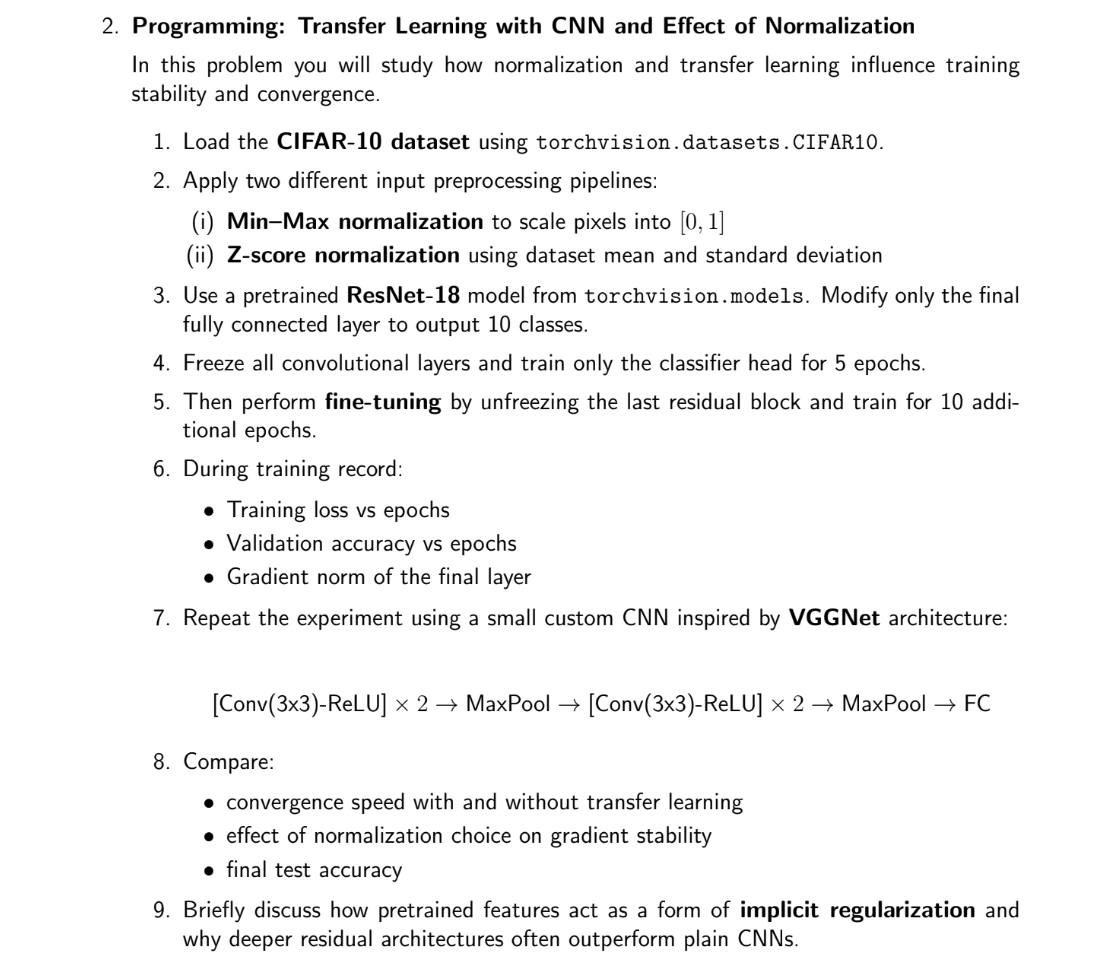

In [2]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#===========================================
# 1. DATA LOADING
#===========================================

def get_dataloaders(norm_type="zscore", batch_size=128):

    if norm_type == "minmax":
        transform = transforms.Compose([
            transforms.ToTensor()  # already scales [0,1]
        ])
    else:
        # CIFAR-10 mean & std
        mean = (0.4914, 0.4822, 0.4465)
        std = (0.2023, 0.1994, 0.2010)

        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])

    dataset = torchvision.datasets.CIFAR10(
        root="./data", train=True, download=True, transform=transform
    )

    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader

#===========================================
# 2. RESNET-18 MODEL
#===========================================

def get_resnet_model():
    model = models.resnet18(pretrained=True)

    # Replace FC layer
    model.fc = nn.Linear(model.fc.in_features, 10)

    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze FC layer
    for param in model.fc.parameters():
        param.requires_grad = True

    return model.to(device)


#===========================================
# 3. UNFREEZE LAST RESIDUAL BLOCK
#===========================================

def unfreeze_last_block(model):
    for param in model.layer4.parameters():
        param.requires_grad = True


#===========================================
# 4. CUSTOM VGG-STYLE CNN
#===========================================

class SimpleVGG(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


#===========================================
# 5. TRAINING FUNCTION
#===========================================

def train_model(model, train_loader, val_loader, epochs, lr=1e-3):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    train_losses = []
    val_accuracies = []
    grad_norms = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()

            # Gradient norm of final layer
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    total_norm += p.grad.data.norm(2).item()
            grad_norms.append(total_norm)

            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_acc = correct / total
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}: Loss={train_loss:.4f}, Val Acc={val_acc:.4f}")

    return train_losses, val_accuracies, grad_norms


#===========================================
# 6. RUN EXPERIMENT
#===========================================

def run_experiment(norm_type="zscore"):

    print(f"\nRunning with {norm_type} normalization\n")

    train_loader, val_loader = get_dataloaders(norm_type)

    # -------- RESNET TRANSFER LEARNING --------
    model = get_resnet_model()

    print("Training classifier head...")
    train_model(model, train_loader, val_loader, epochs=5)

    print("Fine-tuning last block...")
    unfreeze_last_block(model)
    train_model(model, train_loader, val_loader, epochs=10)

    # -------- CUSTOM CNN --------
    print("\nTraining custom CNN from scratch...")
    cnn = SimpleVGG().to(device)
    train_model(cnn, train_loader, val_loader, epochs=15)


#===========================================
# 7. EXECUTE
#===========================================

if __name__ == "__main__":
    run_experiment("minmax")
    run_experiment("zscore")


Running with minmax normalization



100%|██████████| 170M/170M [00:04<00:00, 41.3MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]


Training classifier head...
Epoch 1: Loss=1.8115, Val Acc=0.4246
Epoch 2: Loss=1.6158, Val Acc=0.4480
Epoch 3: Loss=1.5864, Val Acc=0.4565
Epoch 4: Loss=1.5612, Val Acc=0.4605
Epoch 5: Loss=1.5540, Val Acc=0.4556
Fine-tuning last block...
Epoch 1: Loss=1.1477, Val Acc=0.6753
Epoch 2: Loss=0.8048, Val Acc=0.6901
Epoch 3: Loss=0.6331, Val Acc=0.6969
Epoch 4: Loss=0.5016, Val Acc=0.6930
Epoch 5: Loss=0.3903, Val Acc=0.6903
Epoch 6: Loss=0.3073, Val Acc=0.6892
Epoch 7: Loss=0.2525, Val Acc=0.6853
Epoch 8: Loss=0.2147, Val Acc=0.6900
Epoch 9: Loss=0.1720, Val Acc=0.6796
Epoch 10: Loss=0.1562, Val Acc=0.6891

Training custom CNN from scratch...
Epoch 1: Loss=1.6777, Val Acc=0.5042
Epoch 2: Loss=1.2777, Val Acc=0.5814
Epoch 3: Loss=1.0708, Val Acc=0.6280
Epoch 4: Loss=0.9147, Val Acc=0.6793
Epoch 5: Loss=0.7817, Val Acc=0.6857
Epoch 6: Loss=0.6677, Val Acc=0.7123
Epoch 7: Loss=0.5576, Val Acc=0.7083
Epoch 8: Loss=0.4528, Val Acc=0.7077
Epoch 9: Loss=0.3519, Val Acc=0.7133
Epoch 10: Loss=0.268

In [12]:
explain = f'''
pretrained features act as a form of implicit regularization becuase we shall be intalizing the weight to the model of pretrained features.
deeper residual architectures often outperform plain CNNs , in deep layer graident start vanishing but residual architecture prevent from graident vanishing
and keep the gradient flowing
'''
print(explain)


pretrained features act as a form of implicit regularization becuase we shall be intalizing the weight to the model of pretrained features.
deeper residual architectures often outperform plain CNNs , in deep layer graident start vanishing but residual architecture prevent from graident vanishing
and keep the gradient flowing



# Question 4 : U-Net model using a real-world segmentation dataset

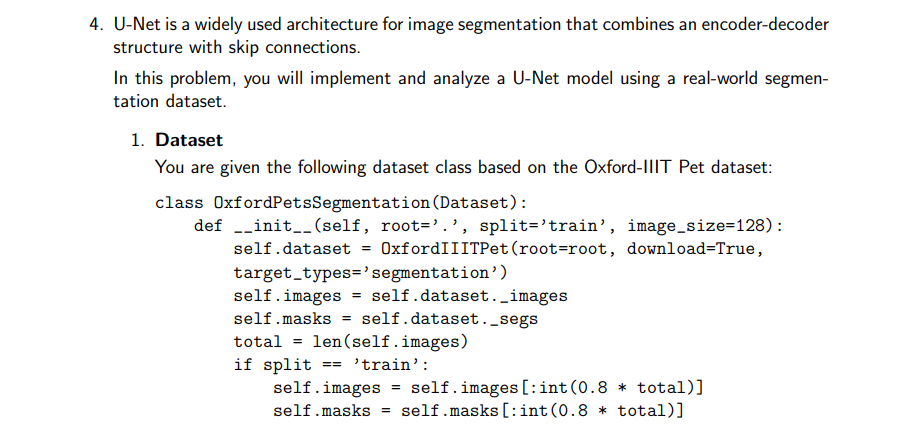

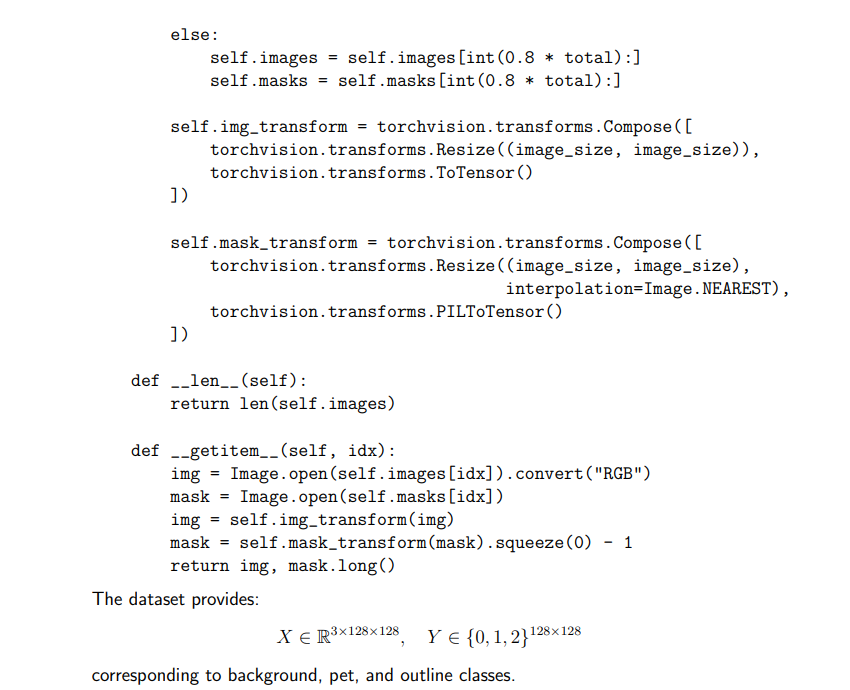

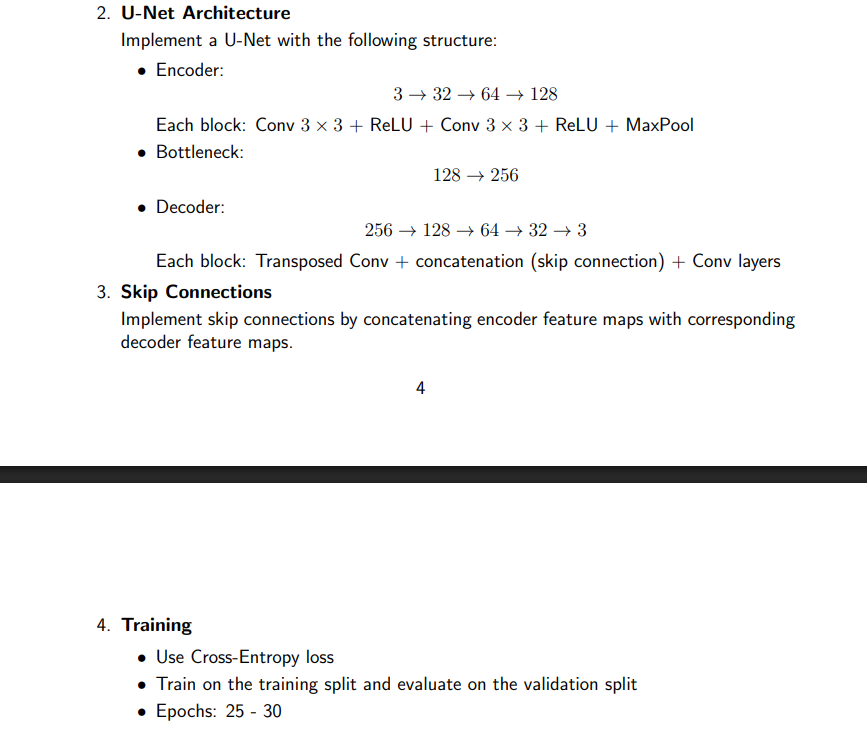

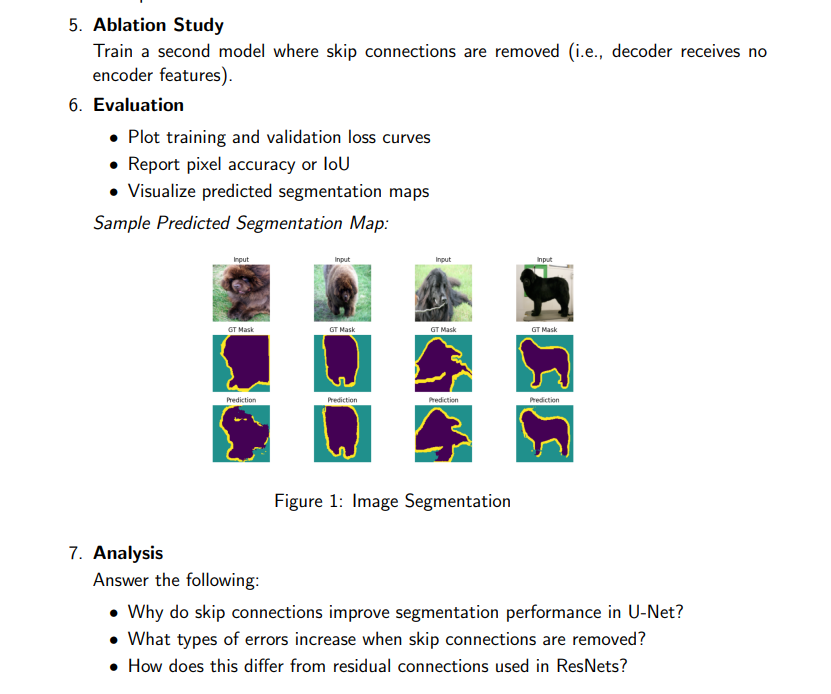

100%|██████████| 792M/792M [00:30<00:00, 26.0MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.6MB/s]



Training U-Net WITH skip connections

Epoch 1: Train=0.8702, Val=0.7118
Epoch 2: Train=0.6787, Val=0.6344
Epoch 3: Train=0.6232, Val=0.6063
Epoch 4: Train=0.5744, Val=0.5514
Epoch 5: Train=0.5334, Val=0.5284
Epoch 6: Train=0.4973, Val=0.4740
Epoch 7: Train=0.4820, Val=0.4783
Epoch 8: Train=0.4620, Val=0.5095
Epoch 9: Train=0.4373, Val=0.4440
Epoch 10: Train=0.4270, Val=0.4400


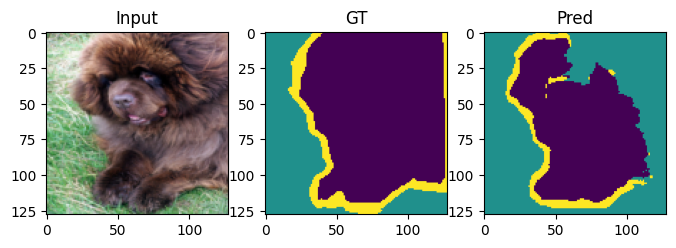

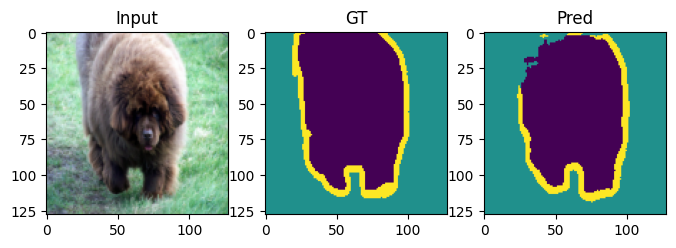

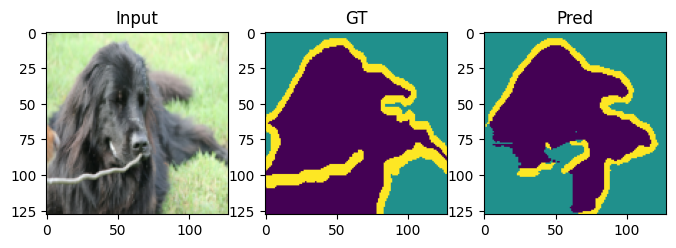


Training U-Net WITHOUT skip connections

Epoch 1: Train=0.8721, Val=0.7709
Epoch 2: Train=0.7655, Val=0.7181
Epoch 3: Train=0.7126, Val=0.6642
Epoch 4: Train=0.6557, Val=0.6287
Epoch 5: Train=0.6084, Val=0.5940
Epoch 6: Train=0.5606, Val=0.5282
Epoch 7: Train=0.5190, Val=0.5211
Epoch 8: Train=0.4963, Val=0.4804
Epoch 9: Train=0.4564, Val=0.4653


In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================================================
# 1. DATASET
# =========================================================
class OxfordPetsSegmentation(Dataset):
    def __init__(self, root='.', split='train', image_size=128):
        self.dataset = OxfordIIITPet(root=root, download=True,
                                     target_types='segmentation')

        self.images = self.dataset._images
        self.masks = self.dataset._segs

        total = len(self.images)

        if split == 'train':
            self.images = self.images[:int(0.8 * total)]
            self.masks = self.masks[:int(0.8 * total)]
        else:
            self.images = self.images[int(0.8 * total):]
            self.masks = self.masks[int(0.8 * total):]

        self.img_transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor()
        ])

        self.mask_transform = transforms.Compose([
            transforms.Resize((image_size, image_size),
                              interpolation=Image.NEAREST),
            transforms.PILToTensor()
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        mask = Image.open(self.masks[idx])

        img = self.img_transform(img)
        mask = self.mask_transform(mask).squeeze(0) - 1

        return img, mask.long()


# =========================================================
# 2. MODEL
# =========================================================
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, num_classes=3, use_skip=True):
        super().__init__()
        self.use_skip = use_skip

        self.enc1 = DoubleConv(3, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec1 = DoubleConv(256 if use_skip else 128, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128 if use_skip else 64, 64)

        self.up3 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec3 = DoubleConv(64 if use_skip else 32, 32)

        self.final = nn.Conv2d(32, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d1 = self.up1(b)
        if self.use_skip:
            d1 = torch.cat([d1, e3], dim=1)
        d1 = self.dec1(d1)

        d2 = self.up2(d1)
        if self.use_skip:
            d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d3 = self.up3(d2)
        if self.use_skip:
            d3 = torch.cat([d3, e1], dim=1)
        d3 = self.dec3(d3)

        return self.final(d3)


# =========================================================
# 3. TRAINING
# =========================================================
def train_model(model, train_loader, val_loader, epochs=10):
    model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_loss = total_loss / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, masks)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}: Train={train_loss:.4f}, Val={val_loss:.4f}")

    return train_losses, val_losses


# =========================================================
# 4. IOU
# =========================================================
def compute_iou(pred, target, num_classes=3):
    pred = torch.argmax(pred, dim=1)
    ious = []

    for cls in range(num_classes):
        pred_inds = (pred == cls)
        target_inds = (target == cls)

        intersection = (pred_inds & target_inds).sum().float()
        union = (pred_inds | target_inds).sum().float()

        if union == 0:
            ious.append(torch.tensor(1.0))
        else:
            ious.append(intersection / union)

    return torch.mean(torch.stack(ious))


# =========================================================
# 5. VISUALIZATION
# =========================================================
def visualize(model, loader):
    model.eval()
    imgs, masks = next(iter(loader))

    imgs = imgs.to(device)

    with torch.no_grad():
        preds = model(imgs)
        preds = torch.argmax(preds, dim=1)

    imgs = imgs.cpu()
    masks = masks.cpu()
    preds = preds.cpu()

    for i in range(3):
        plt.figure(figsize=(8,3))

        plt.subplot(1,3,1)
        plt.imshow(imgs[i].permute(1,2,0))
        plt.title("Input")

        plt.subplot(1,3,2)
        plt.imshow(masks[i])
        plt.title("GT")

        plt.subplot(1,3,3)
        plt.imshow(preds[i])
        plt.title("Pred")

        plt.show()


# =========================================================
# 6. MAIN EXECUTION
# =========================================================
if __name__ == "__main__":

    train_ds = OxfordPetsSegmentation(split='train')
    val_ds = OxfordPetsSegmentation(split='val')

    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=8)

    # -------------------------------
    # WITH SKIP CONNECTIONS
    # -------------------------------
    print("\nTraining U-Net WITH skip connections\n")
    model_skip = UNet(use_skip=True)
    train_model(model_skip, train_loader, val_loader, epochs=10)
    visualize(model_skip, val_loader)

    # -------------------------------
    # WITHOUT SKIP CONNECTIONS
    # -------------------------------
    print("\nTraining U-Net WITHOUT skip connections\n")
    model_noskip = UNet(use_skip=False)
    train_model(model_noskip, train_loader, val_loader, epochs=10)
    visualize(model_noskip, val_loader)

In [13]:
analysis = f'''
Skip connections in U-Net pass high-resolution feature maps from the encoder directly to the decoder (via concatenation).
If you remove skip connections:Blurry boundaries , object edges are poorly defined and Loss of fine details , small structures disappear
'''
print(analysis)


Skip connections in U-Net pass high-resolution feature maps from the encoder directly to the decoder (via concatenation).
If you remove skip connections:Blurry boundaries , object edges are poorly defined and Loss of fine details , small structures disappear



# Question 7 : Programming: preprocessing techniques

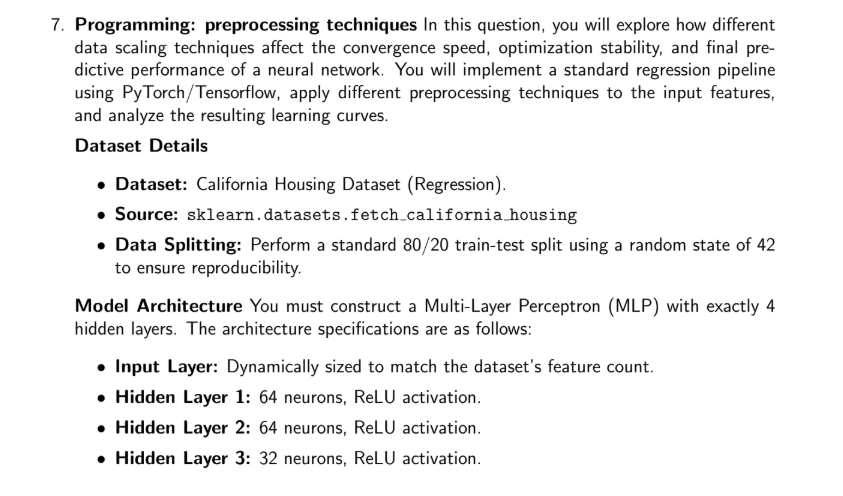

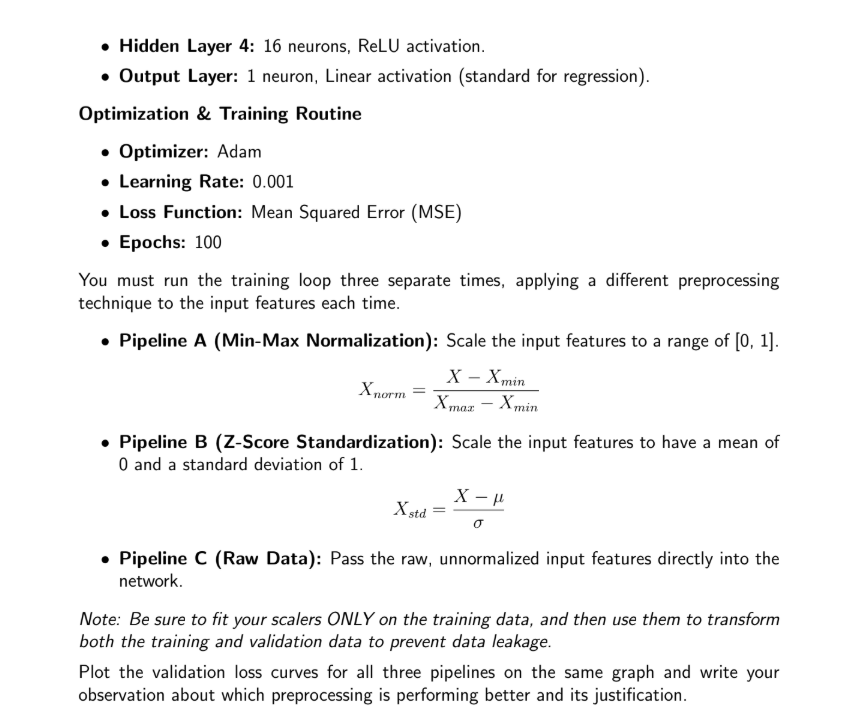

MinMax Epoch 20: Train=4.7680, Val=4.6110
MinMax Epoch 40: Train=1.9413, Val=1.7259
MinMax Epoch 60: Train=1.2203, Val=1.1832
MinMax Epoch 80: Train=1.1231, Val=1.1013
MinMax Epoch 100: Train=1.0527, Val=1.0332
Z-score Epoch 20: Train=4.0054, Val=3.8173
Z-score Epoch 40: Train=1.4395, Val=1.3730
Z-score Epoch 60: Train=0.8523, Val=0.8389
Z-score Epoch 80: Train=0.6759, Val=0.6778
Z-score Epoch 100: Train=0.5908, Val=0.5909
Raw Epoch 20: Train=2.0857, Val=1.9170
Raw Epoch 40: Train=1.3683, Val=1.3109
Raw Epoch 60: Train=1.2864, Val=1.2548
Raw Epoch 80: Train=1.2664, Val=1.2422
Raw Epoch 100: Train=1.2508, Val=1.2262


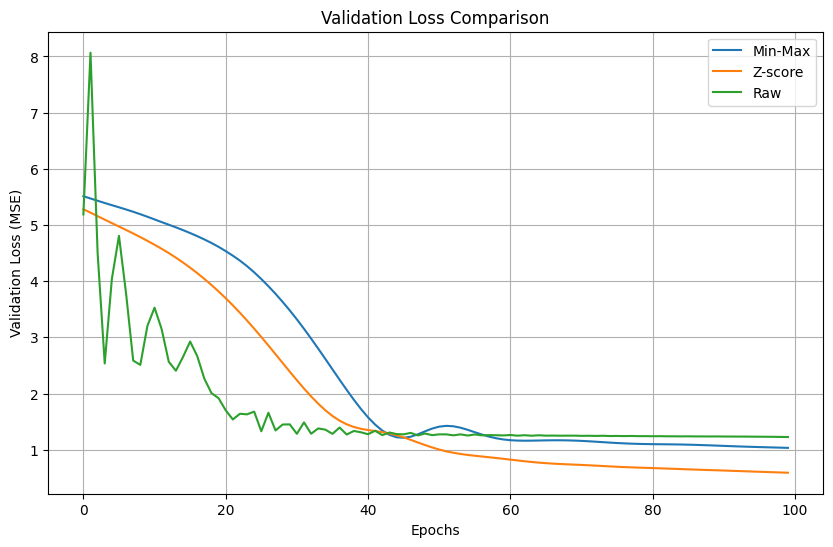

In [10]:

# =========================================
# 1. LOAD DATA
# =========================================
data = fetch_california_housing()
X = data.data
y = data.target.reshape(-1, 1)

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert to tensors helper
def to_tensor(X, y):
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# =========================================
# 2. MODEL (MLP with 4 hidden layers)
# =========================================
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)  # output
        )

    def forward(self, x):
        return self.net(x)

# =========================================
# 3. TRAIN FUNCTION
# =========================================
def train_pipeline(X_train, X_val, y_train, y_val, name):
    model = MLP(X_train.shape[1])
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    train_losses = []
    val_losses = []

    for epoch in range(100):
        model.train()

        pred = model(X_train)
        loss = criterion(pred, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        # Validation
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val)
            val_losses.append(val_loss.item())

        if (epoch+1) % 20 == 0:
            print(f"{name} Epoch {epoch+1}: Train={loss.item():.4f}, Val={val_loss.item():.4f}")

    return train_losses, val_losses

# =========================================
# 4. PIPELINE A (Min-Max)
# =========================================
scaler_minmax = MinMaxScaler()
X_train_A = scaler_minmax.fit_transform(X_train)
X_val_A = scaler_minmax.transform(X_val)

X_train_A, y_train_t = to_tensor(X_train_A, y_train)
X_val_A, y_val_t = to_tensor(X_val_A, y_val)

loss_A_train, loss_A_val = train_pipeline(
    X_train_A, X_val_A, y_train_t, y_val_t, "MinMax"
)

# =========================================
# 5. PIPELINE B (Z-score)
# =========================================
scaler_std = StandardScaler()
X_train_B = scaler_std.fit_transform(X_train)
X_val_B = scaler_std.transform(X_val)

X_train_B, _ = to_tensor(X_train_B, y_train)
X_val_B, _ = to_tensor(X_val_B, y_val)

loss_B_train, loss_B_val = train_pipeline(
    X_train_B, X_val_B, y_train_t, y_val_t, "Z-score"
)

# =========================================
# 6. PIPELINE C (Raw)
# =========================================
X_train_C, _ = to_tensor(X_train, y_train)
X_val_C, _ = to_tensor(X_val, y_val)

loss_C_train, loss_C_val = train_pipeline(
    X_train_C, X_val_C, y_train_t, y_val_t, "Raw"
)

# =========================================
# 7. PLOT RESULTS
# =========================================
plt.figure(figsize=(10,6))

plt.plot(loss_A_val, label="Min-Max")
plt.plot(loss_B_val, label="Z-score")
plt.plot(loss_C_val, label="Raw")

plt.xlabel("Epochs")
plt.ylabel("Validation Loss (MSE)")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid()

plt.show()

# Question 8 : Programming: Hyperparameter tuning (Grid vs. Random Search)

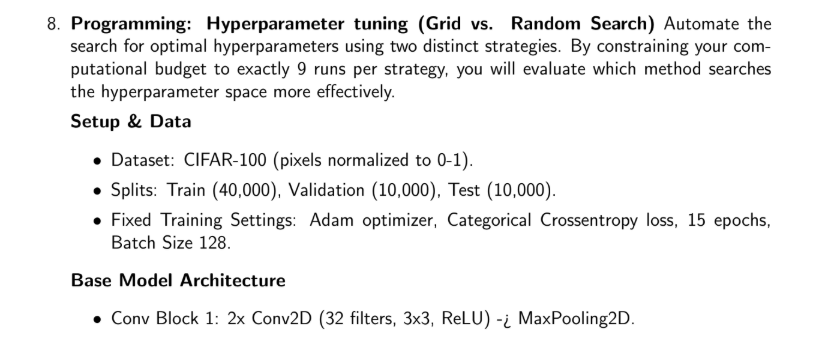

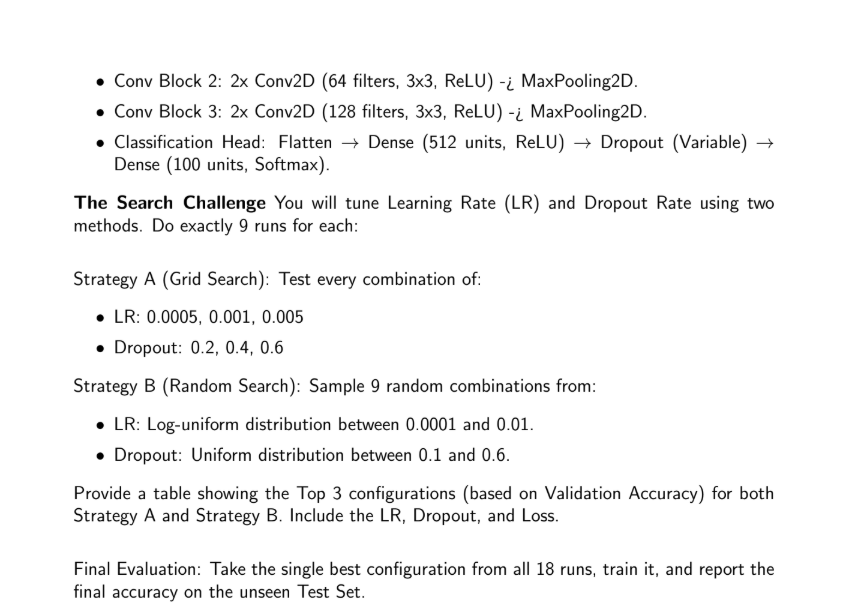

In [11]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# 1.DATASET
# =========================
transform = transforms.Compose([
    transforms.ToTensor()
])

train_full = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

train_set, val_set = torch.utils.data.random_split(train_full, [40000, 10000])

train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=128)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=128)

# =========================
# 2.MODEL
# =========================
class CNN(nn.Module):
    def __init__(self, dropout):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(),
            nn.Conv2d(32,32,3,padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1), nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1), nn.ReLU(),
            nn.Conv2d(128,128,3,padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 100)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# =========================
# 3.TRAIN + EVAL
# =========================
def train_eval(lr, dropout):
    model = CNN(dropout).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    # Train
    for epoch in range(15):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    correct, total = 0, 0
    val_loss = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            val_loss += loss.item()
            preds = out.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct/total, val_loss/len(val_loader)

# =========================
# 4. GRID SEARCH
# =========================
grid_results = []

lrs = [0.0005, 0.001, 0.005]
drops = [0.2, 0.4, 0.6]

print("\nRunning Grid Search...\n")
for lr in lrs:
    for d in drops:
        print(f"Grid: LR={lr}, Dropout={d}")
        acc, loss = train_eval(lr, d)
        grid_results.append([lr, d, acc, loss])

grid_df = pd.DataFrame(grid_results, columns=["LR","Dropout","ValAcc","Loss"])
grid_top3 = grid_df.sort_values(by="ValAcc", ascending=False).head(3)

# =========================
# 5. RANDOM SEARCH
# =========================
random_results = []

print("\nRunning Random Search...\n")
for i in range(9):
    lr = 10 ** np.random.uniform(-4, -2)
    d = np.random.uniform(0.1, 0.6)

    print(f"Random {i+1}: LR={lr:.6f}, Dropout={d:.3f}")
    acc, loss = train_eval(lr, d)

    random_results.append([lr, d, acc, loss])

random_df = pd.DataFrame(random_results, columns=["LR","Dropout","ValAcc","Loss"])
random_top3 = random_df.sort_values(by="ValAcc", ascending=False).head(3)

# =========================
# 6. PRINT RESULTS
# =========================
print("\nTop 3 Grid Search:\n", grid_top3)
print("\nTop 3 Random Search:\n", random_top3)

# =========================
# 7. FINAL BEST MODEL
# =========================
all_results = pd.concat([grid_df, random_df])
best = all_results.sort_values(by="ValAcc", ascending=False).iloc[0]

best_lr = best["LR"]
best_dropout = best["Dropout"]

print("\nBest Config:", best_lr, best_dropout)

model = CNN(best_dropout).to(device)
optimizer = optim.Adam(model.parameters(), lr=best_lr)
criterion = nn.CrossEntropyLoss()

# Train final model
for epoch in range(15):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()

# Test accuracy
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        preds = model(x).argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

print("\nFinal Test Accuracy:", correct/total)

100%|██████████| 169M/169M [00:04<00:00, 37.9MB/s]



Running Grid Search...

Grid: LR=0.0005, Dropout=0.2
Grid: LR=0.0005, Dropout=0.4
Grid: LR=0.0005, Dropout=0.6
Grid: LR=0.001, Dropout=0.2
Grid: LR=0.001, Dropout=0.4
Grid: LR=0.001, Dropout=0.6
Grid: LR=0.005, Dropout=0.2
Grid: LR=0.005, Dropout=0.4
Grid: LR=0.005, Dropout=0.6

Running Random Search...

Random 1: LR=0.002617, Dropout=0.507
Random 2: LR=0.007184, Dropout=0.141
Random 3: LR=0.001908, Dropout=0.511
Random 4: LR=0.000554, Dropout=0.468
Random 5: LR=0.002492, Dropout=0.384
Random 6: LR=0.003827, Dropout=0.552
Random 7: LR=0.006778, Dropout=0.558
Random 8: LR=0.008435, Dropout=0.355
Random 9: LR=0.000566, Dropout=0.498

Top 3 Grid Search:
        LR  Dropout  ValAcc      Loss
5  0.0010      0.6  0.3743  2.493827
1  0.0005      0.4  0.3682  2.543596
4  0.0010      0.4  0.3553  2.580952

Top 3 Random Search:
          LR   Dropout  ValAcc      Loss
8  0.000566  0.498325  0.3853  2.505715
3  0.000554  0.467702  0.3707  2.490703
0  0.002617  0.506761  0.3100  2.792894

Best Co

# Question 10 : Programming: Visualizing Feature Maps in CNN (CIFAR-10)

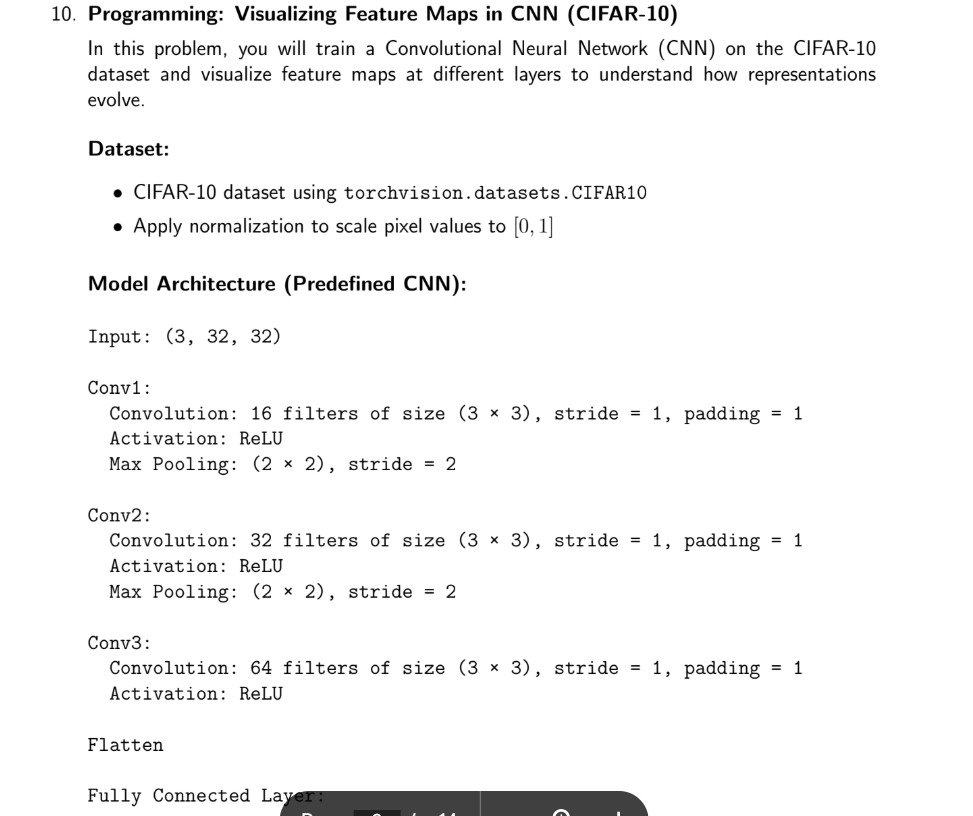

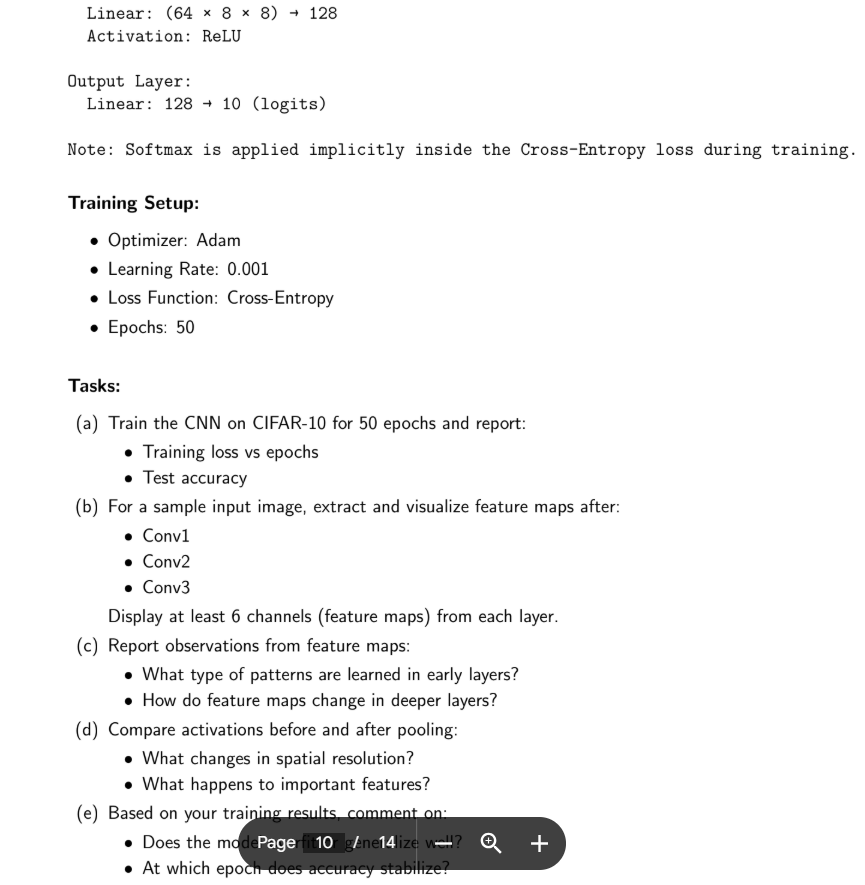

Epoch 1: Loss=1.6193
Epoch 2: Loss=1.2830
Epoch 3: Loss=1.1230
Epoch 4: Loss=1.0154
Epoch 5: Loss=0.9300
Epoch 6: Loss=0.8672
Epoch 7: Loss=0.8030
Epoch 8: Loss=0.7440
Epoch 9: Loss=0.6951
Epoch 10: Loss=0.6375
Epoch 11: Loss=0.5837
Epoch 12: Loss=0.5436
Epoch 13: Loss=0.4944
Epoch 14: Loss=0.4531
Epoch 15: Loss=0.4097
Epoch 16: Loss=0.3601
Epoch 17: Loss=0.3260
Epoch 18: Loss=0.2844
Epoch 19: Loss=0.2518
Epoch 20: Loss=0.2140
Epoch 21: Loss=0.1955
Epoch 22: Loss=0.1555
Epoch 23: Loss=0.1408
Epoch 24: Loss=0.1236
Epoch 25: Loss=0.1158
Epoch 26: Loss=0.1032
Epoch 27: Loss=0.0882
Epoch 28: Loss=0.0722
Epoch 29: Loss=0.0876
Epoch 30: Loss=0.0750
Epoch 31: Loss=0.0600
Epoch 32: Loss=0.0814
Epoch 33: Loss=0.0692
Epoch 34: Loss=0.0668
Epoch 35: Loss=0.0616
Epoch 36: Loss=0.0514
Epoch 37: Loss=0.0527
Epoch 38: Loss=0.0586
Epoch 39: Loss=0.0539
Epoch 40: Loss=0.0486
Epoch 41: Loss=0.0482
Epoch 42: Loss=0.0578
Epoch 43: Loss=0.0524
Epoch 44: Loss=0.0620
Epoch 45: Loss=0.0293
Epoch 46: Loss=0.03

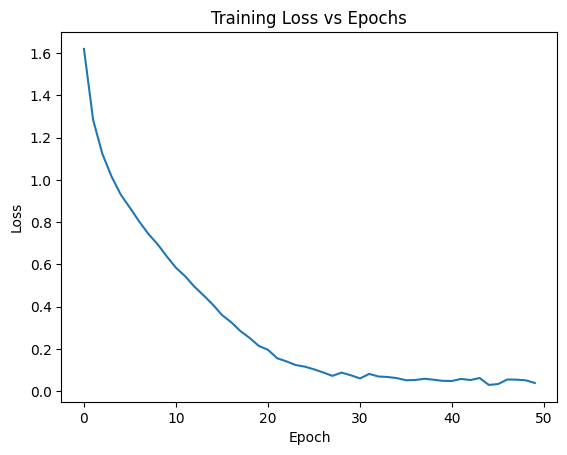

Test Accuracy: 0.693


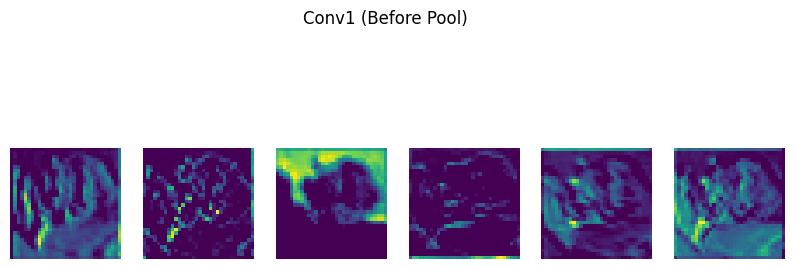

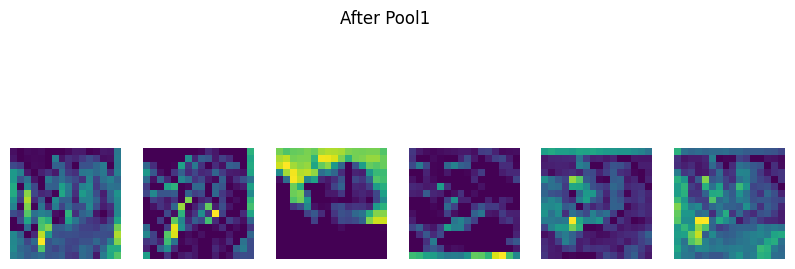

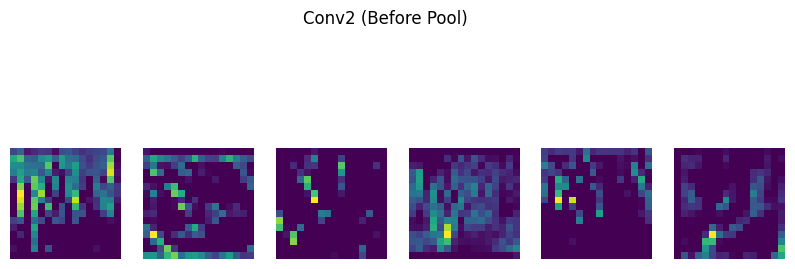

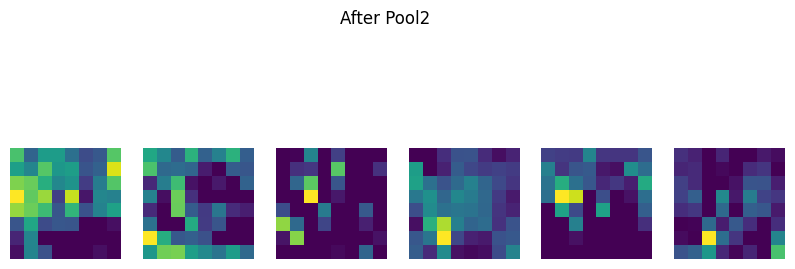

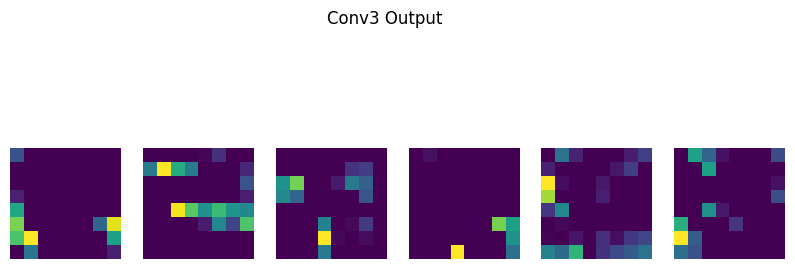

In [14]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================================
# 1. DATA
# =========================================
transform = transforms.Compose([
    transforms.ToTensor()  # already [0,1]
])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=128)

# =========================================
# 2. MODEL
# =========================================
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3,16,3,padding=1)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(16,32,3,padding=1)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(32,64,3,padding=1)

        self.fc1 = nn.Linear(64*8*8,128)
        self.fc2 = nn.Linear(128,10)

    def forward(self, x):
        x1 = torch.relu(self.conv1(x))
        p1 = self.pool1(x1)

        x2 = torch.relu(self.conv2(p1))
        p2 = self.pool2(x2)

        x3 = torch.relu(self.conv3(p2))

        x = x3.view(x3.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x, x1, p1, x2, p2, x3

model = CNN().to(device)

# =========================================
# 3. TRAIN
# =========================================
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_losses = []

for epoch in range(50):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out, *_ = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    epoch_loss = total_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}: Loss={epoch_loss:.4f}")

# =========================================
# 4. PLOT LOSS
# =========================================
plt.plot(train_losses)
plt.title("Training Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# =========================================
# 5. TEST ACCURACY
# =========================================
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out, *_ = model(x)
        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

print("Test Accuracy:", correct/total)

# =========================================
# 6. FEATURE MAP VISUALIZATION
# =========================================
def show_feature_maps(feature_maps, title):
    fmap = feature_maps[0].cpu()  # first image
    plt.figure(figsize=(10,4))
    for i in range(6):
        plt.subplot(1,6,i+1)
        plt.imshow(fmap[i], cmap='viridis')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

# Take one sample
img, _ = test_set[0]
img = img.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    _, x1, p1, x2, p2, x3 = model(img)

# Visualize
show_feature_maps(x1, "Conv1 (Before Pool)")
show_feature_maps(p1, "After Pool1")

show_feature_maps(x2, "Conv2 (Before Pool)")
show_feature_maps(p2, "After Pool2")

show_feature_maps(x3, "Conv3 Output")

In [15]:
analysis = f'''
No , it doesn't overfit the model.
it stablize the accuracy from the epoch 25.
'''
print(analysis)


No , it doesn't overfit the model.
it stablize the accuracy from the epoch 25. 



# Question 14 : Programming: In this problem, you will study the effect of gradient clipping

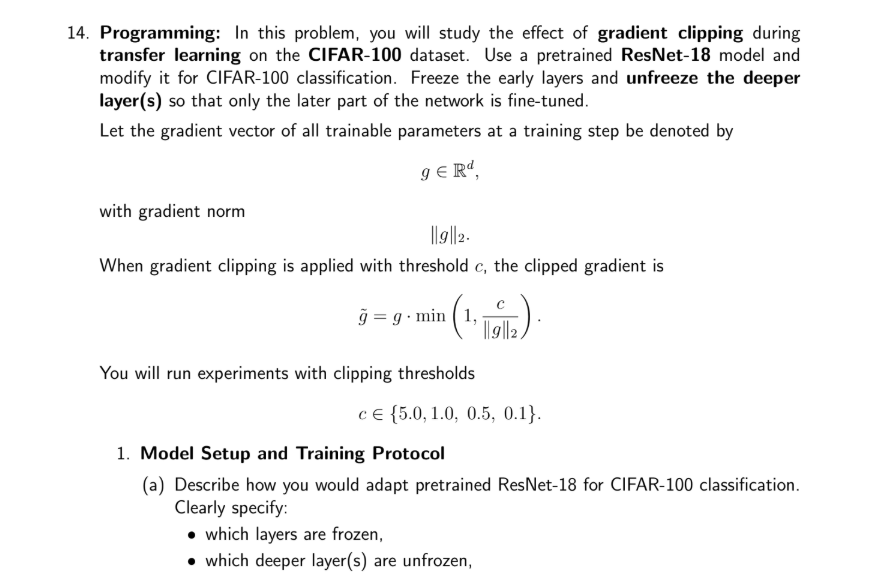

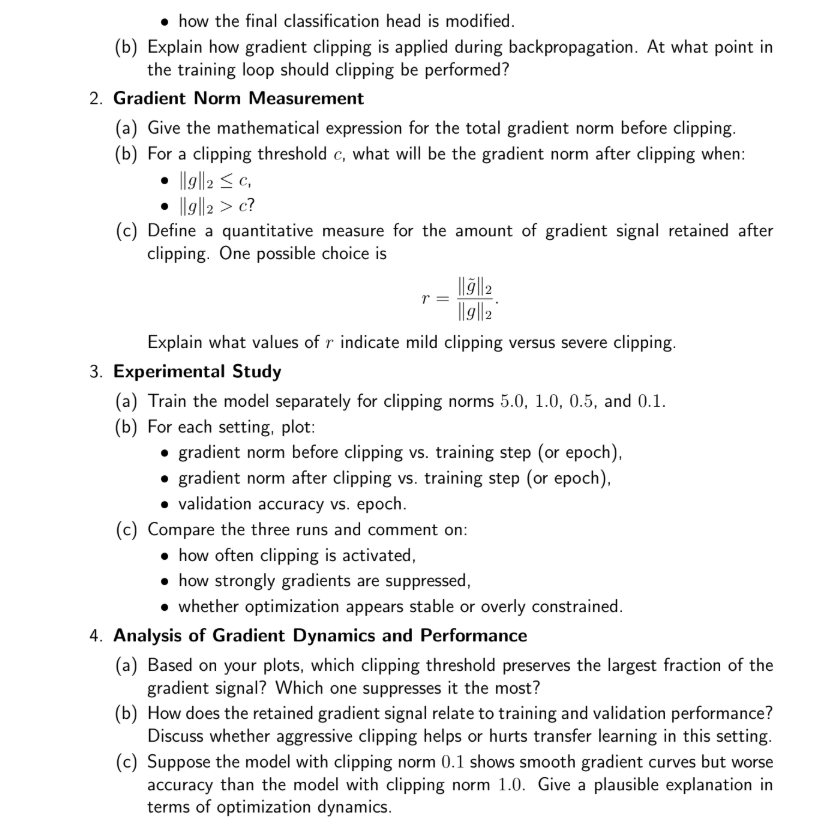


Running for clipping = 5.0


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


c=5.0 Epoch 1 Val Acc=0.6214
c=5.0 Epoch 2 Val Acc=0.6410
c=5.0 Epoch 3 Val Acc=0.6440
c=5.0 Epoch 4 Val Acc=0.6753
c=5.0 Epoch 5 Val Acc=0.6687
c=5.0 Epoch 6 Val Acc=0.6683
c=5.0 Epoch 7 Val Acc=0.6442
c=5.0 Epoch 8 Val Acc=0.6441
c=5.0 Epoch 9 Val Acc=0.6652
c=5.0 Epoch 10 Val Acc=0.6637

Running for clipping = 1.0
c=1.0 Epoch 1 Val Acc=0.6240
c=1.0 Epoch 2 Val Acc=0.6530
c=1.0 Epoch 3 Val Acc=0.6662
c=1.0 Epoch 4 Val Acc=0.6635
c=1.0 Epoch 5 Val Acc=0.6651
c=1.0 Epoch 6 Val Acc=0.6687
c=1.0 Epoch 7 Val Acc=0.6646
c=1.0 Epoch 8 Val Acc=0.6595
c=1.0 Epoch 9 Val Acc=0.6628
c=1.0 Epoch 10 Val Acc=0.6626

Running for clipping = 0.5
c=0.5 Epoch 1 Val Acc=0.6049
c=0.5 Epoch 2 Val Acc=0.6519
c=0.5 Epoch 3 Val Acc=0.6630
c=0.5 Epoch 4 Val Acc=0.6607
c=0.5 Epoch 5 Val Acc=0.6770
c=0.5 Epoch 6 Val Acc=0.6705
c=0.5 Epoch 7 Val Acc=0.6693
c=0.5 Epoch 8 Val Acc=0.6713
c=0.5 Epoch 9 Val Acc=0.6694
c=0.5 Epoch 10 Val Acc=0.6618

Running for clipping = 0.1
c=0.1 Epoch 1 Val Acc=0.6180
c=0.1 Epoch 2 

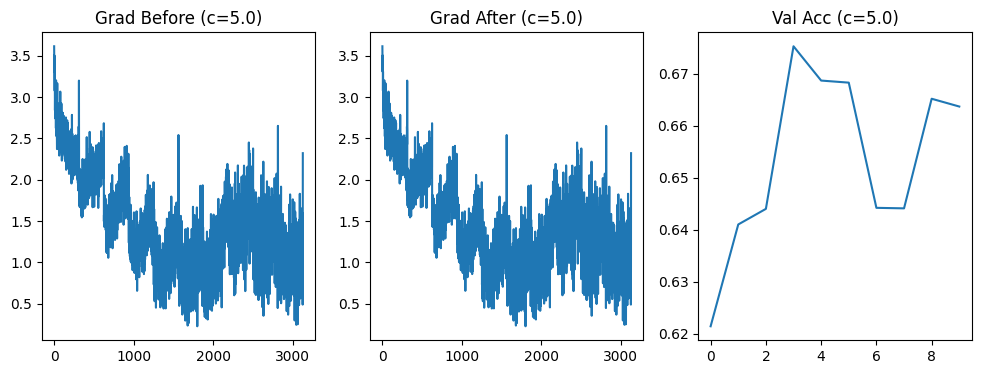

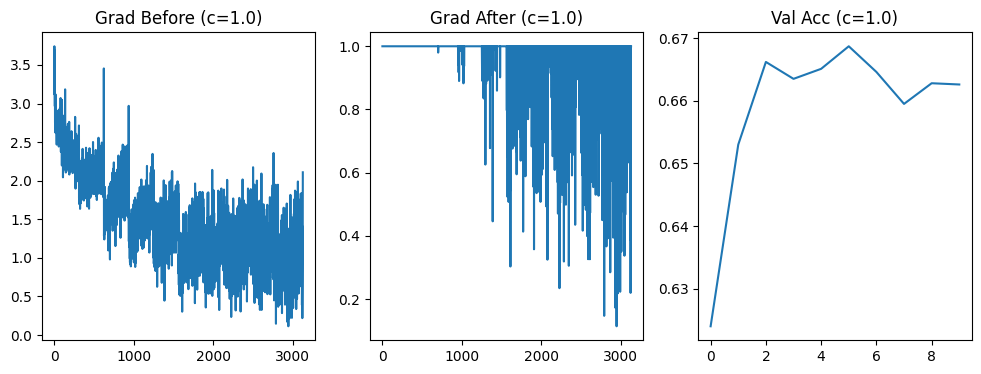

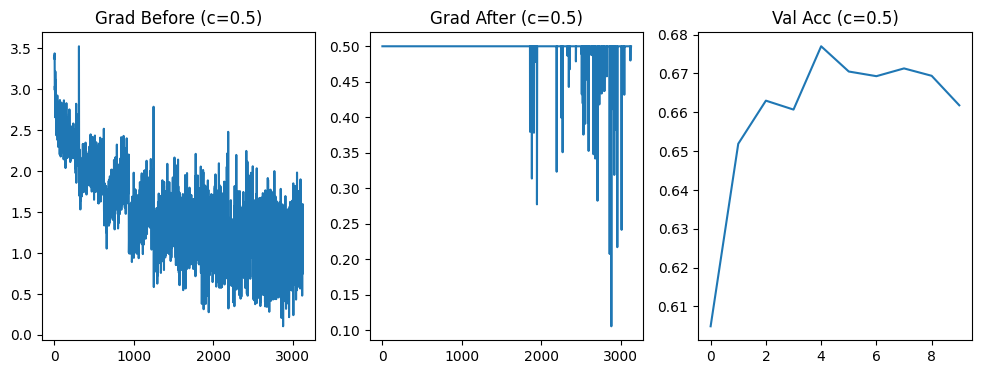

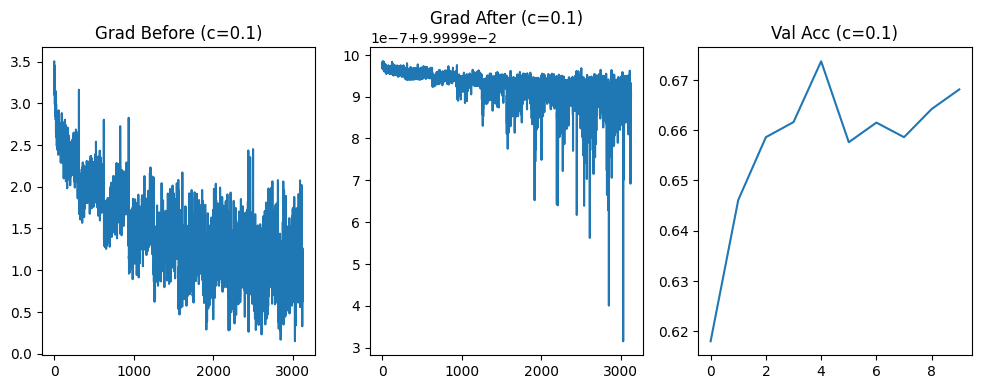

In [16]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================================
# 1. DATA
# =========================================
transform = transforms.Compose([
    transforms.Resize(224),  # ResNet expects larger input
    transforms.ToTensor()
])

train_set = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=128)

# Split validation
train_subset, val_subset = torch.utils.data.random_split(train_set, [40000, 10000])
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=128, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_subset, batch_size=128)

# =========================================
# 2. MODEL (ResNet-18)
# =========================================
def get_model():
    model = torchvision.models.resnet18(pretrained=True)

    # Replace final layer
    model.fc = nn.Linear(model.fc.in_features, 100)

    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze deeper layers (layer4 + fc)
    for param in model.layer4.parameters():
        param.requires_grad = True

    for param in model.fc.parameters():
        param.requires_grad = True

    return model.to(device)

# =========================================
# 3. GRADIENT NORM FUNCTION
# =========================================
def grad_norm(model):
    total_norm = 0
    for p in model.parameters():
        if p.grad is not None:
            total_norm += p.grad.data.norm(2).item()**2
    return total_norm ** 0.5

# =========================================
# 4. TRAIN WITH CLIPPING
# =========================================
def train_with_clipping(c):

    model = get_model()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    grad_before, grad_after, val_accs = [], [], []

    for epoch in range(10):  # reduce for speed
        model.train()

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()

            g_before = grad_norm(model)

            # CLIPPING
            torch.nn.utils.clip_grad_norm_(model.parameters(), c)

            g_after = grad_norm(model)

            optimizer.step()

            grad_before.append(g_before)
            grad_after.append(g_after)

        # Validation
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                preds = model(x).argmax(1)
                correct += (preds == y).sum().item()
                total += y.size(0)

        val_acc = correct / total
        val_accs.append(val_acc)

        print(f"c={c} Epoch {epoch+1} Val Acc={val_acc:.4f}")

    return grad_before, grad_after, val_accs

# =========================================
# 5. RUN EXPERIMENTS
# =========================================
clip_values = [5.0, 1.0, 0.5, 0.1]
results = {}

for c in clip_values:
    print(f"\nRunning for clipping = {c}")
    results[c] = train_with_clipping(c)

# =========================================
# 6. PLOTTING
# =========================================
for c in clip_values:
    g_before, g_after, val_acc = results[c]

    plt.figure(figsize=(12,4))

    # Gradient norms
    plt.subplot(1,3,1)
    plt.plot(g_before)
    plt.title(f"Grad Before (c={c})")

    plt.subplot(1,3,2)
    plt.plot(g_after)
    plt.title(f"Grad After (c={c})")

    # Validation accuracy
    plt.subplot(1,3,3)
    plt.plot(val_acc)
    plt.title(f"Val Acc (c={c})")

    plt.show()

In [19]:
analysis = f'''
A very small clipping threshold (0.1) excessively scales down gradients at almost every step, effectively reducing the learning rate and limiting the optimizer’s ability to make meaningful updates.
Although this produces smooth gradient curves, it leads to underfitting and poorer accuracy compared to a moderate threshold like 1.0, which preserves sufficient gradient signal while still preventing instability.
'''
print(analysis)


A very small clipping threshold (0.1) excessively scales down gradients at almost every step, effectively reducing the learning rate and limiting the optimizer’s ability to make meaningful updates.
Although this produces smooth gradient curves, it leads to underfitting and poorer accuracy compared to a moderate threshold like 1.0, which preserves sufficient gradient signal while still preventing instability.



# Question 15 : Programming: Multi-Channel Convolution and Effect of Stride/Padding

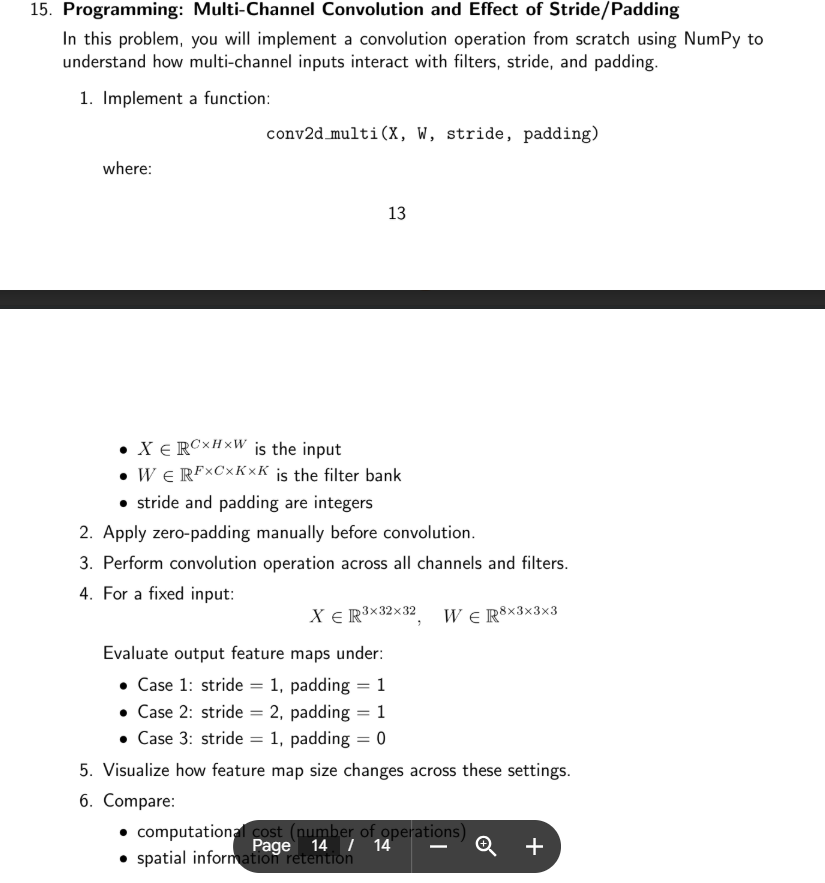

Case 1 (s=1, p=1) → Output shape: (8, 32, 32)
Case 2 (s=2, p=1) → Output shape: (8, 16, 16)
Case 3 (s=1, p=0) → Output shape: (8, 30, 30)

Computational Cost:
Case 1 (s=1, p=1): 221,184 operations
Case 2 (s=2, p=1): 55,296 operations
Case 3 (s=1, p=0): 194,400 operations


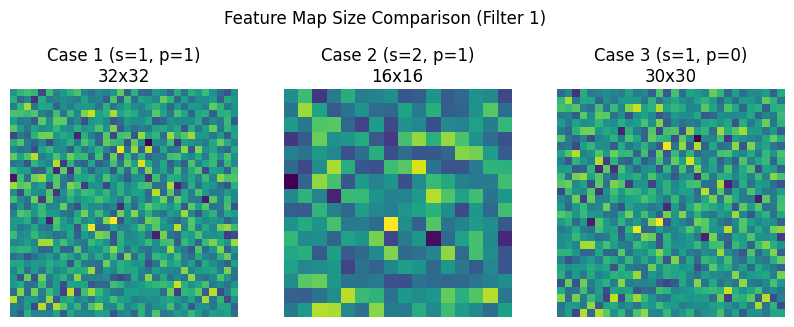

In [17]:

# =========================================
# 1. CONVOLUTION FUNCTION
# =========================================
def conv2d_multi(X, W, stride=1, padding=0):
    """
    X: (C, H, W)
    W: (F, C, K, K)
    """
    C, H, W_in = X.shape
    F, _, K, _ = W.shape

    # Apply padding
    X_padded = np.pad(X, ((0,0), (padding,padding), (padding,padding)), mode='constant')

    H_p, W_p = X_padded.shape[1], X_padded.shape[2]

    # Output dimensions
    H_out = (H_p - K)//stride + 1
    W_out = (W_p - K)//stride + 1

    out = np.zeros((F, H_out, W_out))

    # Convolution
    for f in range(F):
        for i in range(H_out):
            for j in range(W_out):
                h_start = i * stride
                w_start = j * stride

                region = X_padded[:, h_start:h_start+K, w_start:w_start+K]
                out[f, i, j] = np.sum(region * W[f])

    return out

# =========================================
# 2. FIXED INPUT
# =========================================
np.random.seed(0)

X = np.random.randn(3, 32, 32)       # Input
W = np.random.randn(8, 3, 3, 3)      # Filters

# =========================================
# 3. RUN CASES
# =========================================
cases = {
    "Case 1 (s=1, p=1)": (1,1),
    "Case 2 (s=2, p=1)": (2,1),
    "Case 3 (s=1, p=0)": (1,0)
}

results = {}

for name, (s,p) in cases.items():
    out = conv2d_multi(X, W, stride=s, padding=p)
    results[name] = out
    print(f"{name} → Output shape: {out.shape}")

# =========================================
# 4. COMPUTATIONAL COST
# =========================================
def compute_ops(X_shape, W_shape, stride, padding):
    C, H, W = X_shape
    F, _, K, _ = W_shape

    H_out = (H + 2*padding - K)//stride + 1
    W_out = (W + 2*padding - K)//stride + 1

    ops_per_position = C * K * K
    total_ops = F * H_out * W_out * ops_per_position

    return total_ops

print("\nComputational Cost:")
for name, (s,p) in cases.items():
    ops = compute_ops(X.shape, W.shape, s, p)
    print(f"{name}: {ops:,} operations")

# =========================================
# 5. VISUALIZATION (FIRST FILTER)
# =========================================
plt.figure(figsize=(10,4))

for i, (name, out) in enumerate(results.items()):
    plt.subplot(1,3,i+1)
    plt.imshow(out[0], cmap='viridis')
    plt.title(name + f"\n{out.shape[1]}x{out.shape[2]}")
    plt.axis('off')

plt.suptitle("Feature Map Size Comparison (Filter 1)")
plt.show()